# Notebook 2 — Ethanol MD Simulation with MACE-OFF23 (MLIP)

This notebook demonstrates how to run a molecular dynamics simulation of liquid
ethanol using a **machine-learned interatomic potential (MLIP)** — specifically
the [MACE-OFF23](https://arxiv.org/abs/2312.15211) foundation model for organic
molecules.

MACE-OFF23 is a transferable, short-range ML force field trained on
high-level quantum-mechanical (DFT) data.  It can simulate organic liquids
*without* manually assigned atom types or empirical parameters.

## Outline
1. Load the equilibrated ethanol box from Notebook 1
2. Create an OpenMM `System` using `MLPotential('mace-off23-small')`
3. Short NVT production run
4. Save trajectory for MSD analysis

## Performance note

ML potentials are **orders of magnitude** more expensive per step than
classical force fields.  Expect roughly:

| System size | Timestep | GPU speed | CPU speed |
|---|---|---|---|
| 200 molecules (~1800 atoms) | 1 fs | ~5–20 ns/day | ~0.1–0.5 ns/day |

We therefore run a **shorter trajectory** here.  For a classroom demo the
system size can also be reduced (see below).

## 0. Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np

import openmm
import openmm.app as app
import openmm.unit as unit

from openmmml import MLPotential

print(f"OpenMM version: {openmm.__version__}")

OpenMM version: 8.2


## 1. Load the equilibrated configuration

We re-use the PDB file written at the end of the GAFF2 NPT equilibration
(Notebook 1).  This gives us a box at the correct density so we can go
straight to NVT production.

In [2]:
PDB_FILE = "gaff2_topology.pdb"

pdb = app.PDBFile(PDB_FILE)
topology = pdb.topology
positions = pdb.positions

print(f"Loaded {topology.getNumAtoms()} atoms from {PDB_FILE}")
print(f"Box vectors:")
for v in topology.getPeriodicBoxVectors():
    print(f"  {v}")

Loaded 1800 atoms from gaff2_topology.pdb
Box vectors:
  Vec3(x=2.8000000000000003, y=0.0, z=0.0) nm
  Vec3(x=0.0, y=2.8000000000000003, z=0.0) nm
  Vec3(x=0.0, y=0.0, z=2.8000000000000003) nm


## 2. (Optional) Reduce system size for faster demo

If running on CPU or a modest GPU, you may want to use a smaller subset.
Set `USE_FULL_SYSTEM = False` to carve out a smaller box.  For a proper
diffusion calculation, keep the full system.

In [3]:
USE_FULL_SYSTEM = True

if not USE_FULL_SYSTEM:
    from openmm.app import Modeller
    modeller = Modeller(topology, positions)
    # Keep only the first 50 residues (molecules)
    residues = list(topology.residues())
    to_delete = residues[50:]
    modeller.delete(to_delete)
    topology = modeller.topology
    positions = modeller.positions
    print(f"Reduced system: {topology.getNumAtoms()} atoms")
else:
    print(f"Using full system: {topology.getNumAtoms()} atoms")

Using full system: 1800 atoms


## 3. Create the MACE-OFF23 system

The `openmm-ml` package provides `MLPotential`, a high-level interface
that wraps ML models into an OpenMM-compatible `System`.  Under the hood
it uses `openmm-torch` to evaluate the MACE neural-network potential
at every time step.

The model size is part of the potential name.  Available options:
- `'mace-off23-small'` — fastest, slightly less accurate
- `'mace-off23-medium'` — good balance
- `'mace-off23-large'` — most accurate, slowest

We load the model from a local file (`models/MACE-OFF23_small.model`)
bundled with this repository, so no internet access is needed on compute
nodes.

In [4]:
MODEL_PATH = "models/MACE-OFF23_small.model"

potential = MLPotential('mace-off23-small')

system = potential.createSystem(
    topology,
    modelPath=MODEL_PATH,
    precision='single',
)

print(f"MACE-OFF23 system created with {system.getNumParticles()} particles")
print(f"Number of forces: {system.getNumForces()}")
for i in range(system.getNumForces()):
    print(f"  {system.getForce(i).__class__.__name__}")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-OFF23 MODEL for MACECalculator with /home/howziin/.cache/mace/MACE-OFF23_small.model
Model dtype is torch.float64 and requested dtype is torch.float32. The model will be converted to the requested dtype.
MACE-OFF23 system created with 1800 particles
Number of forces: 2
  Force
  CMMotionRemover


## 4. Set up the simulation

Because MACE is an ML potential (no analytical bond constraints), we use
a **1 fs** timestep and no constraints.  We thermostat with Langevin
dynamics at 298.15 K.

In [5]:
TEMPERATURE = 298.15 * unit.kelvin
TIMESTEP = 1.0 * unit.femtosecond
FRICTION = 1.0 / unit.picosecond

integrator = openmm.LangevinMiddleIntegrator(TEMPERATURE, FRICTION, TIMESTEP)

# Use CUDA if available; fall back to CPU
try:
    platform = openmm.Platform.getPlatformByName("CUDA")
    properties = {"Precision": "mixed"}
    print("Using CUDA platform")
except Exception:
    platform = openmm.Platform.getPlatformByName("CPU")
    properties = {}
    print("Using CPU platform (this will be slow)")

simulation = app.Simulation(topology, system, integrator, platform, properties)
simulation.context.setPositions(positions)

Using CUDA platform


### Energy minimization

In [6]:
print("Initial potential energy:",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

simulation.minimizeEnergy(maxIterations=500)

print("After minimization:     ",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

Initial potential energy: -678011.125 kJ/mol


[W308 16:39:38.926216569 LinearAlgebra.cpp:3066] Warning: at::frobenius_norm is deprecated and it is just left for JIT compatibility. It will be removed in a future PyTorch release. Please use `linalg.vector_norm(A, 2., dim, keepdim)` instead (function operator())
[W308 16:39:40.879216086 autograd_not_implemented_fallback.cpp:62] Warning: neighbors::getNeighborPairs: an autograd kernel was not registered to the Autograd key(s) but we are trying to backprop through it. This may lead to silently incorrect behavior. This behavior is deprecated and will be removed in a future version of PyTorch. If your operator is differentiable, please ensure you have registered an autograd kernel to the correct Autograd key (e.g. DispatchKey::Autograd, DispatchKey::CompositeImplicitAutograd). If your operator is not differentiable, or to squash this warning and use the previous behavior, please register torch::CppFunction::makeFallthrough() to DispatchKey::Autograd. (function warnAutogradNotImplemented)

After minimization:      -685740.5 kJ/mol


### Brief NVT equilibration (10 ps)

In [7]:
simulation.context.setVelocitiesToTemperature(TEMPERATURE)

EQUIL_STEPS = 10_000  # 10 ps at 1 fs/step
print(f"Equilibrating for {EQUIL_STEPS} steps (10 ps) ...")
simulation.step(EQUIL_STEPS)
print("Equilibration done.")
print("Temperature:",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

Equilibrating for 10000 steps (10 ps) ...
Equilibration done.
Temperature: -679561.375 kJ/mol


## 5. NVT production run

We save the trajectory with **unwrapped coordinates** (`enforcePeriodicBox=False`)
for the MSD calculation.

**Duration:** 200 ps (200,000 steps at 1 fs).  Increase if time permits.

In [8]:
NVT_STEPS = 200_000       # 200 ps
TRAJ_INTERVAL = 500       # save every 0.5 ps
LOG_INTERVAL = 5000       # log every 5 ps

simulation.reporters.append(
    app.DCDReporter("mace_production.dcd", TRAJ_INTERVAL, enforcePeriodicBox=False)
)
simulation.reporters.append(
    app.StateDataReporter(
        "mace_nvt_log.csv",
        LOG_INTERVAL,
        step=True,
        time=True,
        potentialEnergy=True,
        temperature=True,
    )
)

print(f"Running NVT production for {NVT_STEPS} steps ({NVT_STEPS * 0.001:.0f} ps) ...")
simulation.step(NVT_STEPS)
print("Production run complete.")
print(f"Trajectory saved to mace_production.dcd")
print(f"Frames: {NVT_STEPS // TRAJ_INTERVAL}")

Running NVT production for 200000 steps (200 ps) ...
Production run complete.
Trajectory saved to mace_production.dcd
Frames: 400


## 6. Save topology for analysis

In [9]:
state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)

with open("mace_topology.pdb", "w") as f:
    app.PDBFile.writeFile(topology, state.getPositions(), f)

print("Saved mace_topology.pdb")

Saved mace_topology.pdb


### Quick check — temperature during production

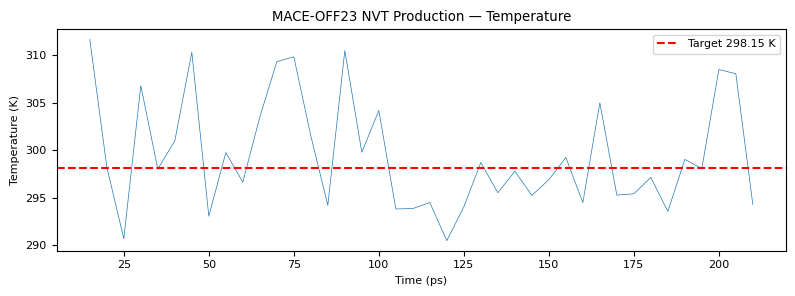

Mean T = 299.45 K
Std  T = 5.91 K


In [10]:
import matplotlib.pyplot as plt

data = np.genfromtxt("mace_nvt_log.csv", delimiter=",", names=True, skip_header=0)

plt.figure(figsize=(8, 3))
plt.plot(data["Time_ps"], data["Temperature_K"], lw=0.5)
plt.axhline(298.15, color="red", ls="--", label="Target 298.15 K")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("MACE-OFF23 NVT Production — Temperature")
plt.legend()
plt.tight_layout()
plt.savefig("mace_nvt_temperature.png", dpi=150)
plt.show()

print(f"Mean T = {data['Temperature_K'].mean():.2f} K")
print(f"Std  T = {data['Temperature_K'].std():.2f} K")

## Summary

| File | Description |
|---|---|
| `mace_topology.pdb` | Topology + final coordinates |
| `mace_production.dcd` | NVT trajectory (unwrapped coords) |
| `mace_nvt_log.csv` | Production thermodynamics |

Proceed to **Notebook 3** for MSD analysis and comparison with GAFF2
and the experimental self-diffusion coefficient.